In [1]:
from lib.helders import *
from lib.data_processing import *
from params import PARAMS

SYMBOL = 'SOLUSDC'

# Load data
blocks = load_from_pickle(PARAMS['base_dir'], SYMBOL)
print(f'Loaded {len(blocks)} blocks')

Loaded 2 blocks


<Figure size 640x480 with 0 Axes>

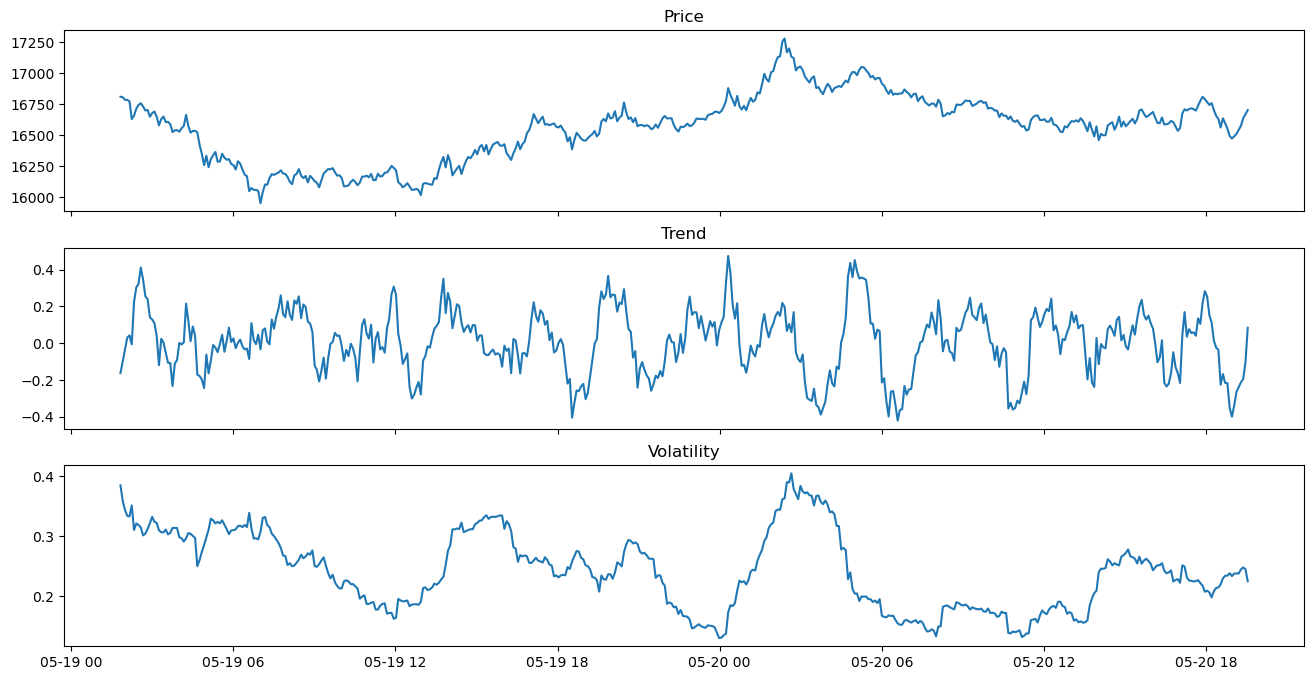

In [2]:
# Indicators example
import random, matplotlib.pyplot as plt
from datetime import datetime

from lib.indicators import *

tf_ms = 300_000
period = 30

# Random block
all_trades, price_step, volume_step = random.choice(blocks)

# Select random index
index = random.randint(all_trades.shape[0] // 8, all_trades.shape[0] // 2)

# Compute indicators
date, price, trend, vlt = [], [], [], []

while index < all_trades.shape[0] and len(date) < 500:
    # Time
    ms = all_trades[index, 0]

    # Get indicators
    t, v, e = get_trend_and_volatility_indicator(all_trades, index, tf_ms, period)
    assert e == 0, f'Error: {e}'

    # Add to lists
    date.append(datetime.fromtimestamp(ms / 1000))
    price.append(all_trades[index, 1])
    trend.append(t)
    vlt.append(v)

    # Move forward
    index = np.searchsorted(all_trades[:, 0], ms + tf_ms)

# Plot
plt.clf()
_, ax = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

ax[0].plot(date, price)
ax[0].set_title('Price')

ax[1].plot(date, trend)
ax[1].set_title('Trend')

ax[2].plot(date, vlt)
ax[2].set_title('Volatility')

plt.show()
